## Postlab Task: Perform Exploratory Data Analysis on Titanic Dataset

This section performs a complete Exploratory Data Analysis (EDA) on the Titanic dataset, covering data loading, descriptive statistics, missing value analysis, and univariate/multivariate visualizations, following the same approach used in Task 2 and Task 3 above.

### Step 1: Load Dataset and Basic Exploration

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ===========================
# Load Titanic Dataset
# ===========================
titanic_df = sns.load_dataset("titanic")

# ===========================
# Display Data
# ===========================
print("First 5 Rows:")
print(titanic_df.head())

print("\nLast 5 Rows:")
print(titanic_df.tail())

print("\nRandom 5 Rows:")
print(titanic_df.sample(5, random_state=1))

# ===========================
# Dataset Information
# ===========================
print("\nShape of Dataset:")
print(titanic_df.shape)

print("\nNumber of Rows:", titanic_df.shape[0])
print("Number of Columns:", titanic_df.shape[1])

print("\nColumn Names:")
print(titanic_df.columns.tolist())

print("\nData Types:")
print(titanic_df.dtypes)

print("\nDataset Information:")
titanic_df.info()

First 5 Rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Last 5 Rows:
     survived  pclass     sex   age  sibsp  parch   fare embarked   class  \
886         0       2    male  27.0      0      0  13.00        S  Second   
887         1       1  female  19.0  

### Step 2: Descriptive Statistical Measures

In [2]:
# ===========================
# Statistical Summary
# ===========================
print("Statistical Summary (Numeric Columns):")
print(titanic_df.describe())

print("\nSummary Including Categorical Columns:")
print(titanic_df.describe(include='all'))

# ===========================
# Central Tendency, Dispersion and Shape for Numeric Features
# ===========================
numeric_cols = ['age', 'fare', 'sibsp', 'parch']

for col in numeric_cols:
    mean_val = titanic_df[col].mean()
    median_val = titanic_df[col].median()
    mode_val = titanic_df[col].mode()[0]
    print(f"Feature: {col}")
    print(f"  Mean:   {mean_val:.4f}")
    print(f"  Median: {median_val:.4f}")
    print(f"  Mode:   {mode_val:.4f}")
    print("-" * 40)

for col in numeric_cols:
    variance = titanic_df[col].var()
    std_dev = titanic_df[col].std()
    data_range = titanic_df[col].max() - titanic_df[col].min()
    q1 = titanic_df[col].quantile(0.25)
    q3 = titanic_df[col].quantile(0.75)
    print(f"Feature: {col}")
    print(f"  Variance:           {variance:.4f}")
    print(f"  Std Deviation:      {std_dev:.4f}")
    print(f"  Range (Max - Min):  {data_range:.4f}")
    print(f"  IQR (Q3 - Q1):      {q3 - q1:.4f}")
    print("-" * 40)

for col in numeric_cols:
    skewness = titanic_df[col].skew()
    kurtosis = titanic_df[col].kurt()
    print(f"Feature: {col}")
    print(f"  Skewness (Asymmetry): {skewness:.4f}")
    print(f"  Kurtosis (Tails):     {kurtosis:.4f}")
    print("-" * 40)

Statistical Summary (Numeric Columns):
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200

Summary Including Categorical Columns:
          survived      pclass   sex         age       sibsp       parch  \
count   891.000000  891.000000   891  714.000000  891.000000  891.000000   
unique         NaN         NaN     2         NaN         NaN       

In [3]:
# ===========================
# Group-Wise Statistics by Survival Status
# ===========================
grouped_survived = titanic_df.groupby('survived')

print("--- Group-Wise Mean Values (by Survival) ---")
print(grouped_survived[numeric_cols].mean())

print("\n--- Group-Wise Standard Deviation (by Survival) ---")
print(grouped_survived[numeric_cols].std())

# ===========================
# Group-Wise Statistics by Passenger Class
# ===========================
grouped_class = titanic_df.groupby('pclass')

print("\n--- Group-Wise Mean Fare by Passenger Class ---")
print(grouped_class['fare'].mean())

aggregated_stats = titanic_df.groupby('pclass')['age'].agg(['mean', 'median', 'std', 'skew'])
print("\nAggregated Statistics (Age by Class):\n", aggregated_stats)

--- Group-Wise Mean Values (by Survival) ---
                age       fare     sibsp     parch
survived                                          
0         30.626179  22.117887  0.553734  0.329690
1         28.343690  48.395408  0.473684  0.464912

--- Group-Wise Standard Deviation (by Survival) ---
                age       fare     sibsp     parch
survived                                          
0         14.172110  31.388207  1.288399  0.823166
1         14.950952  66.596998  0.708688  0.771712

--- Group-Wise Mean Fare by Passenger Class ---
pclass
1    84.154687
2    20.662183
3    13.675550
Name: fare, dtype: float64

Aggregated Statistics (Age by Class):
              mean  median        std      skew
pclass                                        
1       38.233441    37.0  14.802856  0.119857
2       29.877630    29.0  14.001077  0.133837
3       25.140620    24.0  12.495398  0.483990


### Step 3: Missing Values, Duplicates and Unique Values

In [4]:
# ===========================
# Missing Values
# ===========================
print("Missing Values:")
print(titanic_df.isnull().sum())

print("\nPercentage of Missing Values:")
print((titanic_df.isnull().sum() / len(titanic_df) * 100).round(2))

# ===========================
# Duplicate Values
# ===========================
print("\nDuplicate Rows:")
print(titanic_df.duplicated().sum())

# ===========================
# Unique Values
# ===========================
print("\nUnique Values in Each Column:")
print(titanic_df.nunique())

print("\nUnique Passenger Classes:")
print(titanic_df["class"].unique())

print("\nSurvival Counts:")
print(titanic_df['survived'].value_counts())

Missing Values:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Percentage of Missing Values:
survived        0.00
pclass          0.00
sex             0.00
age            19.87
sibsp           0.00
parch           0.00
fare            0.00
embarked        0.22
class           0.00
who             0.00
adult_male      0.00
deck           77.22
embark_town     0.22
alive           0.00
alone           0.00
dtype: float64

Duplicate Rows:
107

Unique Values in Each Column:
survived         2
pclass           3
sex              2
age             88
sibsp            7
parch            7
fare           248
embarked         3
class            3
who              3
adult_male       2
deck             7
embark_town      3
alive            2
alone  

### Step 4: Univariate Visualization

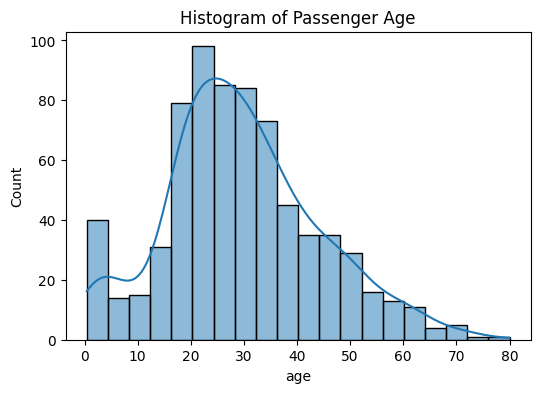

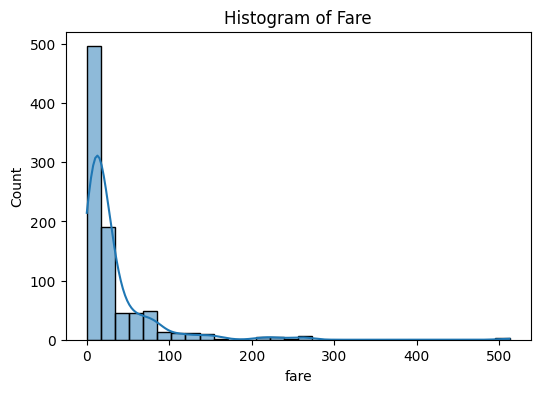

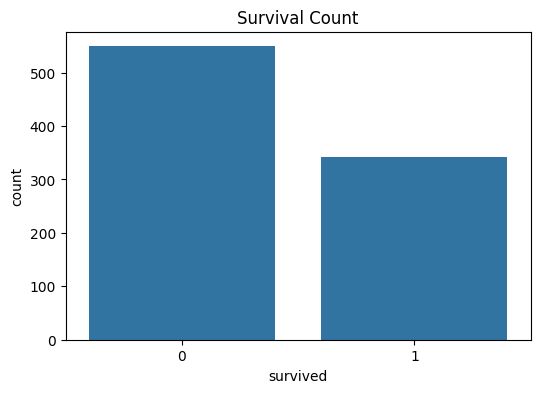

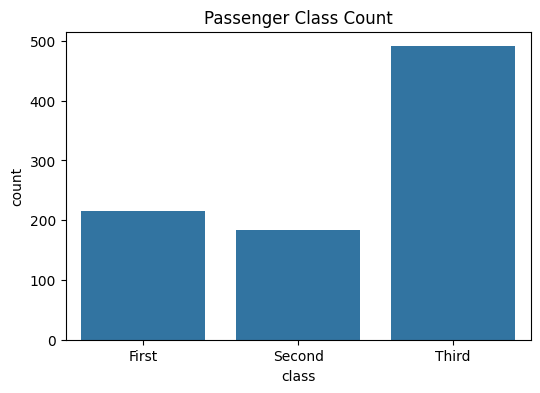

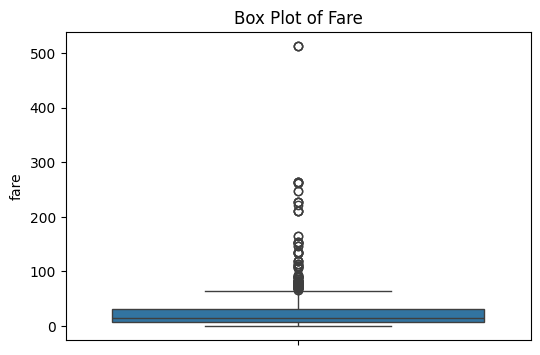

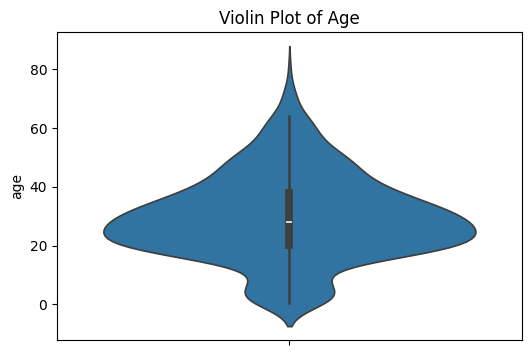

In [5]:
# Histogram - Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(titanic_df["age"].dropna(), bins=20, kde=True)
plt.title("Histogram of Passenger Age")
plt.show()

# Histogram - Fare Distribution
plt.figure(figsize=(6,4))
sns.histplot(titanic_df["fare"], bins=30, kde=True)
plt.title("Histogram of Fare")
plt.show()

# Count Plot - Survived
plt.figure(figsize=(6,4))
sns.countplot(x="survived", data=titanic_df)
plt.title("Survival Count")
plt.show()

# Count Plot - Passenger Class
plt.figure(figsize=(6,4))
sns.countplot(x="class", data=titanic_df)
plt.title("Passenger Class Count")
plt.show()

# Box Plot - Fare
plt.figure(figsize=(6,4))
sns.boxplot(y="fare", data=titanic_df)
plt.title("Box Plot of Fare")
plt.show()

# Violin Plot - Age
plt.figure(figsize=(6,4))
sns.violinplot(y="age", data=titanic_df)
plt.title("Violin Plot of Age")
plt.show()

### Step 5: Multivariate Visualization

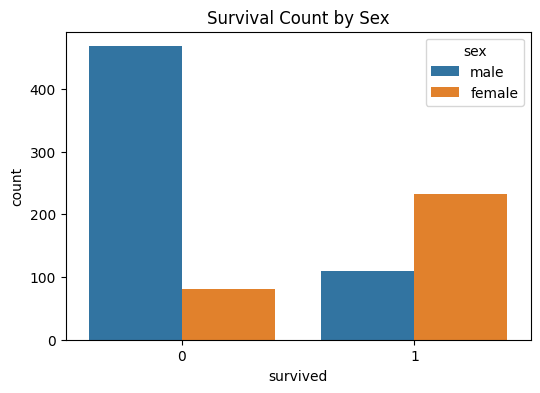

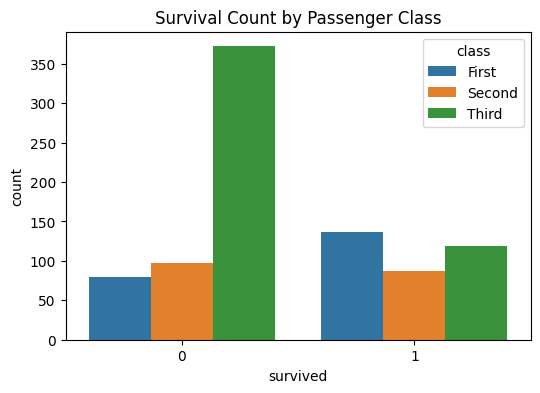

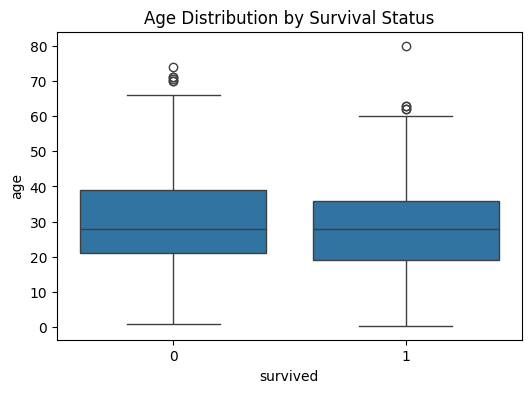

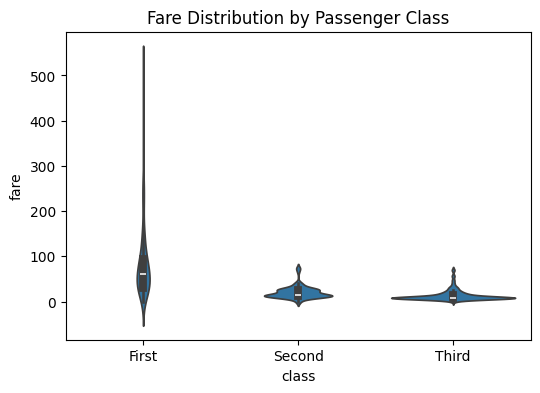

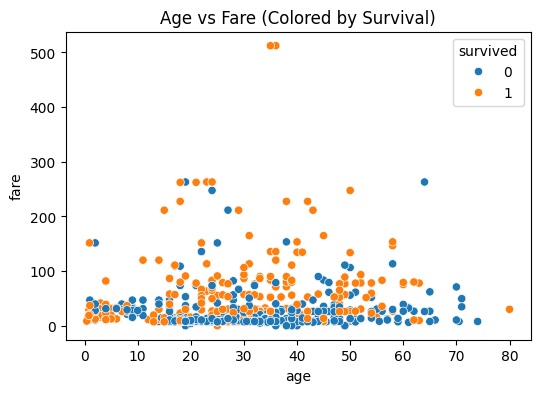

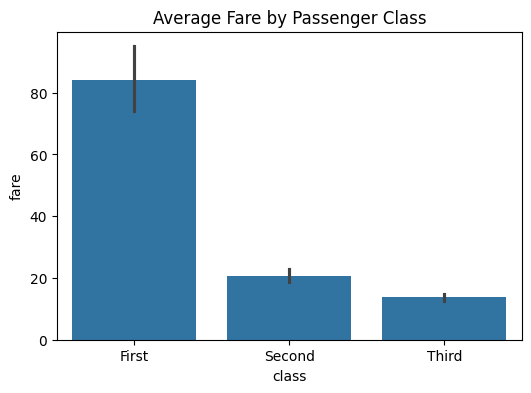

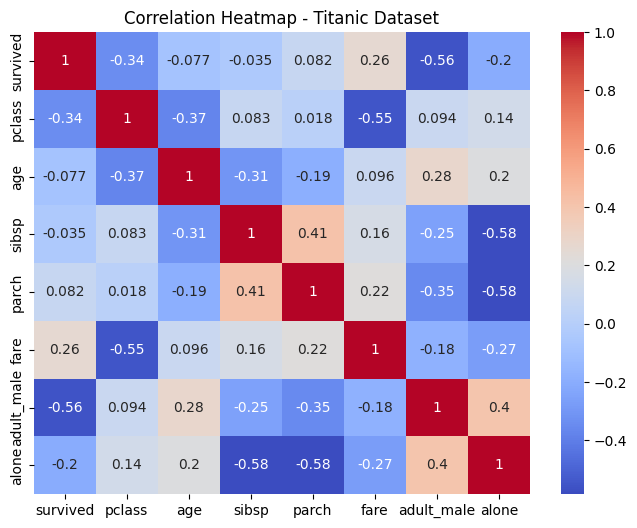

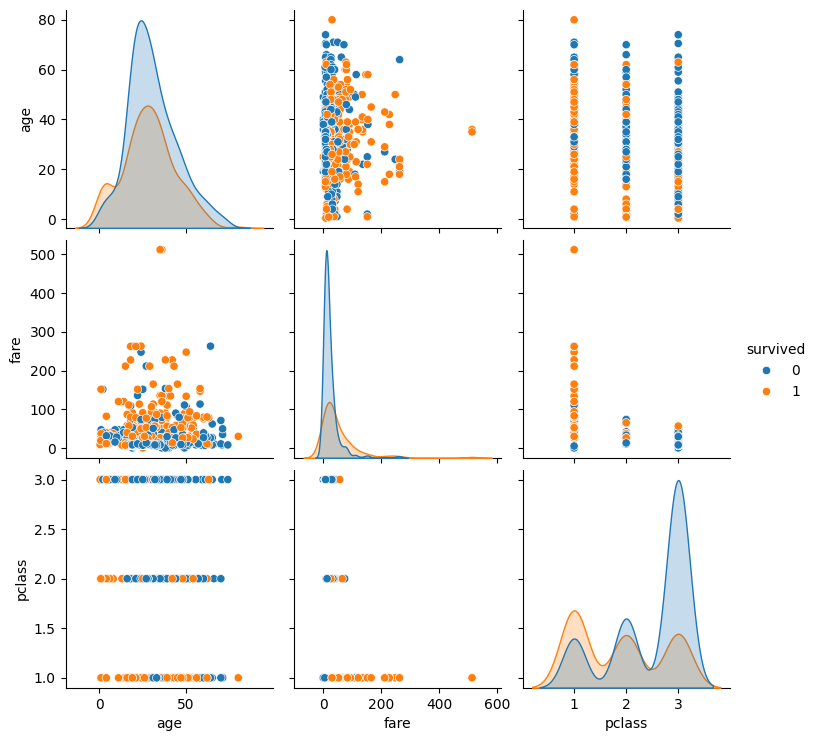

In [6]:
# Survival Count by Sex
plt.figure(figsize=(6,4))
sns.countplot(x="survived", hue="sex", data=titanic_df)
plt.title("Survival Count by Sex")
plt.show()

# Survival Count by Passenger Class
plt.figure(figsize=(6,4))
sns.countplot(x="survived", hue="class", data=titanic_df)
plt.title("Survival Count by Passenger Class")
plt.show()

# Box Plot of Age by Survival Status
plt.figure(figsize=(6,4))
sns.boxplot(x="survived", y="age", data=titanic_df)
plt.title("Age Distribution by Survival Status")
plt.show()

# Violin Plot of Fare by Passenger Class
plt.figure(figsize=(6,4))
sns.violinplot(x="class", y="fare", data=titanic_df)
plt.title("Fare Distribution by Passenger Class")
plt.show()

# Scatter Plot - Age vs Fare colored by Survival
plt.figure(figsize=(6,4))
sns.scatterplot(x="age", y="fare", hue="survived", data=titanic_df)
plt.title("Age vs Fare (Colored by Survival)")
plt.show()

# Bar Plot - Average Fare by Passenger Class
plt.figure(figsize=(6,4))
sns.barplot(x="class", y="fare", data=titanic_df)
plt.title("Average Fare by Passenger Class")
plt.show()

# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(titanic_df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Titanic Dataset")
plt.show()

# Pair Plot for key numeric features
sns.pairplot(titanic_df[["age", "fare", "pclass", "survived"]].dropna(), hue="survived")
plt.show()

### Step 6: Observations / Inferences

- The Titanic dataset has 891 rows and 15 columns, with a mix of numeric (age, fare, sibsp, parch) and categorical (sex, class, embarked) features.
- The `age` column has a considerable number of missing values (~177), and `deck` has a very high proportion of missing values, while `embarked`/`embark_town` have only a few missing entries.
- The overall survival rate is below 50%, and survival is visibly higher among female passengers and passengers travelling in higher (1st) class.
- `fare` is highly right-skewed, with a small number of passengers paying very high fares, while most fares are concentrated at the lower end.
- Passengers in 1st class tend to be older on average and paid substantially higher fares than 2nd and 3rd class passengers.
- The correlation heatmap shows a strong negative correlation between `pclass` and `fare`, and a positive correlation between `fare` and `survived`, suggesting wealthier passengers had a higher chance of survival.